# 03 - Preprocessing con corte temporal hasta 2025

Este notebook prepara los datos de exoplanetas TESS para PCA y clustering. Mantiene exactamente las 12 variables seleccionadas en los notebooks 01 y 02, pero excluye los descubrimientos de 2026 **antes de ajustar transformaciones, escalado e imputación**.

## Resumen ejecutivo

- Entrada: 910 exoplanetas y 355 columnas.
- Corte temporal: `disc_year <= 2025`.
- Registros fuera del corte: 171 descubrimientos de 2026.
- Regla de completitud: al menos 8 de las 12 mediciones.
- Salida esperada: 675 planetas, 12 variables, cero nulos y cero infinitos.
- Tratamiento: `log1p` selectivo, `RobustScaler` e imputación KNN con 5 vecinos.

Los datos de 2026 no se borran del catálogo original: quedan identificados en la auditoría con su motivo de exclusión.

## Bloque 1. Configuración reproducible

Se centralizan las rutas, variables y parámetros del pipeline. `MAX_DISCOVERY_YEAR = 2025` convierte el corte temporal en una regla visible, auditable y reutilizable.

El orden de `FEATURE_COLUMNS` forma parte del contrato entre preprocessing y PCA.

In [1]:
# BLOQUE 1 — Importaciones, variables, rutas y parámetros

from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, RobustScaler, StandardScaler

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 60)

RAW_DATA_PATH = Path("data/raw/exoplanets.csv")
PROCESSED_DATA_PATH = Path("data/processed/exoplanets_preprocessed.csv")
SELECTED_RAW_DATA_PATH = Path("data/processed/exoplanets_selected_raw.csv")
ROW_AUDIT_PATH = Path("data/processed/preprocessing_row_audit.csv")
QUALITY_SUMMARY_PATH = Path("data/processed/preprocessing_quality_summary.csv")
SCALER_COMPARISON_PATH = Path("data/processed/preprocessing_scaler_comparison.csv")
IMPUTER_COMPARISON_PATH = Path("data/processed/preprocessing_imputer_comparison.csv")
PIPELINE_PATH = Path("data/processed/preprocessing_pipeline.joblib")
METADATA_PATH = Path("data/processed/preprocessing_metadata.json")

ID_COLUMN = "pl_name"
YEAR_COLUMN = "disc_year"
MAX_DISCOVERY_YEAR = 2025

PLANET_FEATURES = [
    "pl_orbper",
    "pl_orbsmax",
    "pl_rade",
    "pl_bmasse",
    "pl_orbeccen",
    "pl_insol",
    "pl_eqt",
]
STELLAR_FEATURES = [
    "st_teff",
    "st_rad",
    "st_mass",
    "st_met",
    "st_logg",
]
FEATURE_COLUMNS = PLANET_FEATURES + STELLAR_FEATURES

LOG1P_FEATURES = [
    "pl_orbper",
    "pl_orbsmax",
    "pl_rade",
    "pl_bmasse",
    "pl_insol",
    "st_rad",
]
LINEAR_FEATURES = [feature for feature in FEATURE_COLUMNS if feature not in LOG1P_FEATURES]

MIN_PRESENT_FEATURES = 8
SCALER_NAME = "robust"
KNN_NEIGHBORS = 5
KNN_WEIGHTS = "distance"
RANDOM_STATE = 42
MASKING_RATE = 0.10
EXPORT_ARTIFACTS = True

NASA_SOURCE_URL = (
    "https://exoplanetarchive.ipac.caltech.edu/cgi-bin/TblView/"
    "nph-tblView?app=ExoTbls&config=PS&constraint=default_flag=1"
    "&constraint=disc_facility+like+%27%25TESS%25%27"
)

### Conclusión del bloque 1

La configuración deja visibles las 12 variables, el corte máximo en 2025, el mínimo de 8 mediciones, el escalado robusto y los 5 vecinos de KNN.

## Bloque 2. Localización y carga

Se carga el catálogo original completo. Todavía no se elimina ninguna fila: primero se valida la estructura para conservar una auditoría de las 910 observaciones.

In [2]:
# BLOQUE 2 — Localizar el proyecto y cargar el CSV

def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "README.md").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("No se encontró la raíz de exoplanet-profiler.")

PROJECT_ROOT = find_project_root()
raw_data_path = PROJECT_ROOT / RAW_DATA_PATH

if not raw_data_path.exists():
    raise FileNotFoundError(
        f"No existe {raw_data_path}. Descarga primero el CSV TESS de NASA."
    )

df_raw = pd.read_csv(raw_data_path, comment="#", low_memory=False)

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Dataset cargado: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas")
display(df_raw[[ID_COLUMN, YEAR_COLUMN, *FEATURE_COLUMNS]].head())

Raíz del proyecto: C:\PROYECTOS_ELE\BOOTCAMP_MODULO3\proyecto2_modulo3\exoplanet-profiler
Dataset cargado: 910 filas x 355 columnas


,pl_name,disc_year,pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_orbeccen,pl_insol,pl_eqt,st_teff,st_rad,st_mass,st_met,st_logg
0,pi Men c,2018,6.267840,NaN,2.018900,NaN,0.000,NaN,NaN,5998.0,1.170,1.070,0.090,4.430
1,LHS 3844 b,2019,0.462930,0.00624,1.286000,2.370000,0.000,73.67,816.0,3080.0,0.189,0.151,0.220,5.070
2,HD 202772 A b,2019,3.308877,0.05208,18.237012,323.549318,0.030,3770.00,2181.0,6442.0,2.554,1.721,0.232,3.930
3,GJ 143 b,2019,35.612530,0.19150,2.610000,22.700000,0.188,NaN,422.0,4640.0,0.695,0.730,0.003,4.613
4,HD 23472 b,2019,17.667087,0.11620,2.000000,8.320000,0.072,16.00,543.0,4684.0,0.710,0.670,-0.200,4.530


### Conclusión del bloque 2

El extracto contiene **910 filas y 355 columnas**. Cada fila representa un planeta y `pl_name` mantiene su identidad durante todo el proceso.

## Bloque 3. Validación de estructura y granularidad



Antes de transformar datos se comprueba que existen el identificador y las 12 variables, que no hay planetas sin nombre y que no existen identificadores o filas duplicadas. Si falla una condición estructural, el notebook se detiene con un mensaje claro.

In [3]:
# BLOQUE 3 — Comprobar columnas, identificadores y duplicados

required_columns = [ID_COLUMN, YEAR_COLUMN, *FEATURE_COLUMNS]
missing_required = [column for column in required_columns if column not in df_raw.columns]
if missing_required:
    raise ValueError(f"Faltan columnas requeridas: {missing_required}")

structural_checks = pd.Series(
    {
        "filas": len(df_raw),
        "columnas": df_raw.shape[1],
        "identificadores_nulos": int(df_raw[ID_COLUMN].isna().sum()),
        "identificadores_duplicados": int(df_raw[ID_COLUMN].duplicated().sum()),
        "años_nulos": int(df_raw[YEAR_COLUMN].isna().sum()),
        "filas_duplicadas_exactas": int(df_raw.duplicated().sum()),
    },
    name="resultado",
)
display(structural_checks.to_frame())

if structural_checks["identificadores_nulos"]:
    raise ValueError(f"{ID_COLUMN} contiene nulos.")
if structural_checks["identificadores_duplicados"]:
    duplicated = df_raw.loc[df_raw[ID_COLUMN].duplicated(), ID_COLUMN].head().tolist()
    raise ValueError(f"{ID_COLUMN} contiene duplicados: {duplicated}")
if structural_checks["años_nulos"]:
    raise ValueError(f"{YEAR_COLUMN} contiene nulos.")

,resultado
filas,910
columnas,355
identificadores_nulos,0
identificadores_duplicados,0
años_nulos,0
filas_duplicadas_exactas,0


### Conclusión del bloque 3

La unidad de análisis es consistente: no hay identificadores nulos o duplicados, años ausentes ni filas exactamente duplicadas.

## Bloque 4. Conversión numérica, reglas físicas y corte temporal

Las 12 variables y `disc_year` se convierten explícitamente a valores numéricos. Después se aplican reglas físicas básicas y el corte `disc_year <= 2025`.

El corte ocurre antes de cualquier ajuste del pipeline para impedir que 2026 influya en transformaciones, escalas, vecinos o imputaciones.

In [5]:
# BLOQUE 4 — Convertir tipos, validar rangos y aplicar el corte temporal

df_validated = df_raw[[ID_COLUMN, YEAR_COLUMN, *FEATURE_COLUMNS]].copy()
df_validated[YEAR_COLUMN] = pd.to_numeric(df_validated[YEAR_COLUMN], errors="coerce")

nulls_before_cast = df_validated[FEATURE_COLUMNS].isna().sum()
for feature in FEATURE_COLUMNS:
    df_validated[feature] = pd.to_numeric(df_validated[feature], errors="coerce")
nulls_after_cast = df_validated[FEATURE_COLUMNS].isna().sum()
introduced_nulls = (nulls_after_cast - nulls_before_cast).clip(lower=0)

if df_validated[YEAR_COLUMN].isna().any():
    raise ValueError("La conversión de disc_year introdujo valores nulos.")
if introduced_nulls.sum() > 0:
    raise ValueError(
        "La conversión numérica introdujo nulos: "
        + str(introduced_nulls[introduced_nulls > 0].to_dict())
    )

positive_features = [
    "pl_orbper",
    "pl_orbsmax",
    "pl_rade",
    "pl_bmasse",
    "pl_insol",
    "pl_eqt",
    "st_teff",
    "st_rad",
    "st_mass",
    "st_logg",
]
validity_rows = []
for feature in positive_features:
    validity_rows.append(
        {
            "regla": f"{feature} > 0",
            "violaciones": int((df_validated[feature].dropna() <= 0).sum()),
        }
    )

eccentricity = df_validated["pl_orbeccen"].dropna()
validity_rows.append(
    {
        "regla": "0 <= pl_orbeccen <= 1",
        "violaciones": int(((eccentricity < 0) | (eccentricity > 1)).sum()),
    }
)
validity_df = pd.DataFrame(validity_rows)
display(validity_df)

if validity_df["violaciones"].sum() > 0:
    raise ValueError("Se detectaron valores incompatibles con las reglas físicas.")

temporal_eligible_mask = df_validated[YEAR_COLUMN] <= MAX_DISCOVERY_YEAR
df_model = df_validated.loc[
    temporal_eligible_mask,
    [ID_COLUMN, *FEATURE_COLUMNS],
].copy()

temporal_summary = pd.Series(
    {
        "filas_catálogo": len(df_validated),
        "año_máximo_admitido": MAX_DISCOVERY_YEAR,
        "filas_hasta_2025": int(temporal_eligible_mask.sum()),
        "filas_2026_excluidas": int((~temporal_eligible_mask).sum()),
    },
    name="resultado",
)
display(temporal_summary.to_frame())

assert int((~temporal_eligible_mask).sum()) == 171
assert df_validated.loc[temporal_eligible_mask, YEAR_COLUMN].max() <= 2025

,regla,violaciones
0,pl_orbper > 0,0
1,pl_orbsmax > 0,0
2,pl_rade > 0,0
3,pl_bmasse > 0,0
4,pl_insol > 0,0
5,pl_eqt > 0,0
6,st_teff > 0,0
7,st_rad > 0,0
8,st_mass > 0,0
9,st_logg > 0,0


,resultado
filas_catálogo,910
año_máximo_admitido,2025
filas_hasta_2025,739
filas_2026_excluidas,171


### Conclusión del bloque 4

No se detectan violaciones físicas. Se excluyen **171 descubrimientos de 2026** y quedan **739 planetas elegibles** antes del filtro de completitud.

## Bloque 5. Diagnóstico de valores ausentes hasta 2025

La cobertura y la completitud se calculan únicamente sobre los 739 planetas dentro del corte temporal. Así, las decisiones de imputación no reciben influencia de 2026.

In [6]:
# BLOQUE 5A — Medir nulos por variable


missingness_before = pd.DataFrame(
    {
        "presentes": df_model[FEATURE_COLUMNS].notna().sum(),
        "nulos": df_model[FEATURE_COLUMNS].isna().sum(),
        "porcentaje_nulos": df_model[FEATURE_COLUMNS].isna().mean() * 100,
    }
).sort_values("porcentaje_nulos", ascending=False)

display(missingness_before.round(2))

,presentes,nulos,porcentaje_nulos
pl_insol,365,374,50.61
pl_bmasse,572,167,22.60
pl_orbeccen,579,160,21.65
pl_eqt,617,122,16.51
st_met,630,109,14.75
pl_orbsmax,650,89,12.04
st_logg,654,85,11.50
st_teff,716,23,3.11
pl_rade,729,10,1.35
st_mass,730,9,1.22


,planetas,porcentaje
variables_presentes,,
2,1,0.14
5,1,0.14
6,15,2.03
7,47,6.36
8,50,6.77
9,68,9.20
10,82,11.10
11,242,32.75
12,233,31.53


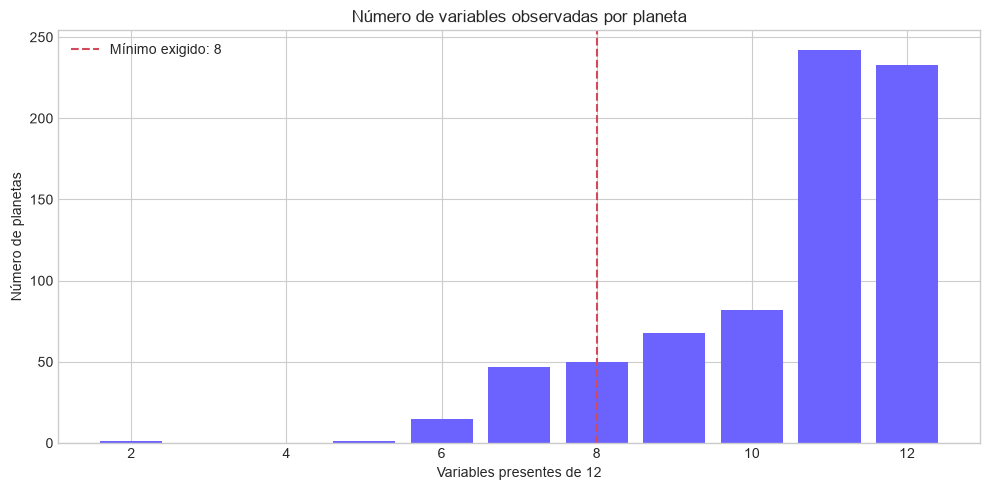

In [7]:
# BLOQUE 5B — Contar mediciones presentes por planeta


# Contamos cuántas de las 12 variables están observadas en cada planeta.
present_feature_count = df_model[FEATURE_COLUMNS].notna().sum(axis=1)
completeness_distribution = (
    present_feature_count.value_counts()
    .sort_index()
    .rename_axis("variables_presentes")
    .to_frame("planetas")
)
completeness_distribution["porcentaje"] = (
    completeness_distribution["planetas"] / len(df_model) * 100
)
display(completeness_distribution.round(2))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    completeness_distribution.index,
    completeness_distribution["planetas"],
    color="#6C63FF",
)
ax.axvline(
    MIN_PRESENT_FEATURES,
    color="#D1495B",
    linestyle="--",
    label=f"Mínimo exigido: {MIN_PRESENT_FEATURES}",
)
ax.set(
    title="Número de variables observadas por planeta",
    xlabel="Variables presentes de 12",
    ylabel="Número de planetas",
)
ax.legend()
fig.tight_layout()
plt.show()

### Conclusión del bloque 5

En los 739 planetas elegibles, `pl_insol` presenta **50,61 % de nulos**. Hay **233 casos completos**; utilizar únicamente filas completas descartaría demasiada información.

## Bloque 6. Filtro de completitud por planeta



Se conservan filas con al menos 8 variables observadas. Así se mantienen todas las columnas candidatas, pero nunca se reconstruye más de un tercio del perfil de un planeta. Se genera además una auditoría con el número de mediciones y el motivo de inclusión o exclusión.

In [8]:
# BLOQUE 6 — Aplicar el umbral de 8 mediciones y construir la auditoría

completeness_mask_eligible = present_feature_count >= MIN_PRESENT_FEATURES
retained_mask = pd.Series(False, index=df_validated.index)
retained_mask.loc[df_model.index] = completeness_mask_eligible

df_retained = df_validated.loc[
    retained_mask,
    [ID_COLUMN, *FEATURE_COLUMNS],
].copy()

all_present_count = df_validated[FEATURE_COLUMNS].notna().sum(axis=1)
row_audit = pd.DataFrame(
    {
        ID_COLUMN: df_validated[ID_COLUMN],
        YEAR_COLUMN: df_validated[YEAR_COLUMN].astype(int),
        "elegible_por_año": temporal_eligible_mask,
        "variables_presentes": all_present_count,
        "variables_ausentes": len(FEATURE_COLUMNS) - all_present_count,
        "cumple_completitud": all_present_count >= MIN_PRESENT_FEATURES,
        "retenido": retained_mask,
        "columnas_ausentes": df_validated[FEATURE_COLUMNS].apply(
            lambda row: ",".join(row.index[row.isna()].tolist()),
            axis=1,
        ),
    }
)
row_audit["motivo_exclusion"] = np.select(
    [
        ~row_audit["elegible_por_año"],
        ~row_audit["cumple_completitud"],
    ],
    [
        "fuera_corte_temporal_2026",
        "menos_de_8_mediciones",
    ],
    default="retenido",
)

retention_summary = pd.Series(
    {
        "filas_originales": len(df_validated),
        "excluidas_por_año_2026": int((~temporal_eligible_mask).sum()),
        "filas_elegibles_hasta_2025": len(df_model),
        "excluidas_por_completitud_hasta_2025": int(
            (~completeness_mask_eligible).sum()
        ),
        "filas_retenidas": int(retained_mask.sum()),
        "porcentaje_retenido_sobre_catálogo": float(retained_mask.mean() * 100),
        "casos_completos_hasta_2025": int(
            df_model[FEATURE_COLUMNS].notna().all(axis=1).sum()
        ),
        "porcentaje_celdas_a_imputar_en_retenidos": float(
            df_retained[FEATURE_COLUMNS].isna().mean().mean() * 100
        ),
    },
    name="resultado",
)
display(retention_summary.to_frame().round(2))

assert int(retained_mask.sum()) == 675
assert row_audit.loc[row_audit["retenido"], YEAR_COLUMN].max() <= 2025

,resultado
filas_originales,910.00
excluidas_por_año_2026,171.00
filas_elegibles_hasta_2025,739.00
excluidas_por_completitud_hasta_2025,64.00
filas_retenidas,675.00
porcentaje_retenido_sobre_catálogo,74.18
casos_completos_hasta_2025,233.00
porcentaje_celdas_a_imputar_en_retenidos,10.00


### Conclusión del bloque 6

De los 910 planetas, 171 se excluyen por pertenecer a 2026. Entre los 739 elegibles hasta 2025, 64 no alcanzan ocho mediciones. La muestra final contiene **675 planetas**.

## Bloque 7. Riesgo de imputación después del filtro



El filtro mejora la completitud por fila, pero no garantiza que todas las columnas sean igual de fiables. Se vuelve a medir la ausencia y se asigna un nivel de riesgo para destacar variables que dependerán mucho del imputador.

In [9]:
# BLOQUE 7 — Revisar los nulos de la muestra retenida


missingness_retained = pd.DataFrame(
    {
        "nulos_en_retenidos": df_retained[FEATURE_COLUMNS].isna().sum(),
        "porcentaje_nulos_en_retenidos": (
            df_retained[FEATURE_COLUMNS].isna().mean() * 100
        ),
    }
).sort_values("porcentaje_nulos_en_retenidos", ascending=False)

missingness_retained["nivel_riesgo"] = np.where(
    missingness_retained["porcentaje_nulos_en_retenidos"] >= 40,
    "alto",
    np.where(
        missingness_retained["porcentaje_nulos_en_retenidos"] >= 20,
        "medio",
        "bajo",
    ),
)
display(missingness_retained.round(2))

,nulos_en_retenidos,porcentaje_nulos_en_retenidos,nivel_riesgo
pl_insol,342,50.67,alto
pl_bmasse,112,16.59,bajo
pl_orbeccen,108,16.00,bajo
pl_eqt,78,11.56,bajo
pl_orbsmax,64,9.48,bajo
st_met,51,7.56,bajo
st_logg,36,5.33,bajo
st_teff,11,1.63,bajo
pl_rade,8,1.19,bajo
pl_orbper,0,0.00,bajo


### Conclusión del bloque 7

`pl_insol` continúa siendo el principal riesgo: falta en **342 de 675 planetas (50,67 %)**. El resto de variables queda por debajo del 17 % de ausencia en la muestra retenida.

## Bloque 8. Auditoría temporal y motivos de exclusión

Se muestran el total, la elegibilidad temporal, la completitud y la retención por año. En 2026 la retención es cero por una regla previa y explícita, no por falta de calidad individual.

In [10]:
# BLOQUE 8 — Auditar elegibilidad y retención por año

retention_by_year = (
    row_audit.groupby(YEAR_COLUMN, dropna=False)
    .agg(
        total=(ID_COLUMN, "size"),
        elegibles_por_año=("elegible_por_año", "sum"),
        cumplen_completitud=("cumple_completitud", "sum"),
        retenidos=("retenido", "sum"),
    )
    .reset_index()
)
retention_by_year["porcentaje_retenido"] = (
    retention_by_year["retenidos"] / retention_by_year["total"] * 100
)
display(retention_by_year.tail(10).round(2))

exclusion_reasons = (
    row_audit["motivo_exclusion"]
    .value_counts()
    .rename_axis("motivo")
    .to_frame("planetas")
)
display(exclusion_reasons)

,disc_year,total,elegibles_por_año,cumplen_completitud,retenidos,porcentaje_retenido
0,2018,3,3,3,3,100.00
1,2019,33,33,30,30,90.91
2,2020,68,68,64,64,94.12
3,2021,77,77,71,71,92.21
4,2022,111,111,104,104,93.69
5,2023,140,140,133,133,95.00
6,2024,178,178,150,150,84.27
7,2025,129,129,120,120,93.02
8,2026,171,0,58,0,0.00


,planetas
motivo,
retenido,675
fuera_corte_temporal_2026,171
menos_de_8_mediciones,64


### Conclusión del bloque 8

La auditoría distingue dos decisiones: **171 registros** quedan fuera por el corte temporal de 2026 y **64 registros elegibles** se excluyen por completitud. Los 675 retenidos pertenecen a años completos hasta 2025.

## Bloque 9. Auditoría de valores extremos



La regla del rango intercuartílico identifica observaciones alejadas del centro de cada distribución. Se utiliza solo como diagnóstico: en astronomía, un valor extremo puede ser un planeta real y científicamente interesante, no un error.

In [11]:
# BLOQUE 9 — Resumir outliers con la regla IQR


def iqr_outlier_summary(frame: pd.DataFrame) -> pd.DataFrame:
    # Los límites IQR sirven para describir extremos, no para borrarlos.
    rows = []
    for feature in frame.columns:
        values = frame[feature].dropna()
        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        count = int(((values < lower) | (values > upper)).sum())
        rows.append(
            {
                "variable": feature,
                "limite_inferior": lower,
                "limite_superior": upper,
                "outliers_iqr": count,
                "porcentaje_outliers": count / len(values) * 100,
            }
        )
    return pd.DataFrame(rows).set_index("variable")


outlier_summary = iqr_outlier_summary(df_retained[FEATURE_COLUMNS])
display(outlier_summary.round(3))

,limite_inferior,limite_superior,outliers_iqr,porcentaje_outliers
variable,,,,
pl_orbper,-10.890,26.794,71,10.519
pl_orbsmax,-0.063,0.205,52,8.511
pl_rade,-11.321,24.751,1,0.150
pl_bmasse,-371.929,640.148,68,12.078
pl_orbeccen,-0.210,0.350,39,6.878
pl_insol,-898.750,1544.050,17,5.105
pl_eqt,-486.000,2410.000,2,0.335
st_teff,1142.125,8723.125,0,0.000
st_rad,-0.356,2.228,21,3.111


### Conclusión del bloque 9

Hay extremos especialmente en periodo orbital, masa, semieje y excentricidad. **No se elimina ni winsoriza ninguna fila**. Su influencia se reduce mediante transformaciones y escalado robusto, conservando la diversidad física del catálogo.

## Bloque 10. Transformación de distribuciones asimétricas



`log1p(x)` Comprime colas largas y admite el valor cero. Se aplica de forma selectiva a periodo, semieje, radio planetario, masa planetaria, insolación y radio estelar. Un `ColumnTransformer` independiente por variable preserva exactamente el orden acordado.

In [12]:
# BLOQUE 10 — Construir y revisar las transformaciones por variable


def build_feature_transformer() -> ColumnTransformer:
    # Se crea un transformador por variable para preservar exactamente
    # el orden PLANET_FEATURES + STELLAR_FEATURES en la salida.
    transformers = []
    for feature in FEATURE_COLUMNS:
        if feature in LOG1P_FEATURES:
            transformer = FunctionTransformer(
                np.log1p,
                validate=False,
                feature_names_out="one-to-one",
            )
        else:
            transformer = "passthrough"
        transformers.append((feature, transformer, [feature]))

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False,
    )


feature_transformer_for_audit = build_feature_transformer()
transformed_array = feature_transformer_for_audit.fit_transform(
    df_retained[FEATURE_COLUMNS]
)
transformed_names = feature_transformer_for_audit.get_feature_names_out().tolist()

if transformed_names != FEATURE_COLUMNS:
    raise RuntimeError(f"Orden inesperado de variables: {transformed_names}")

transformed_df = pd.DataFrame(
    transformed_array,
    columns=FEATURE_COLUMNS,
    index=df_retained.index,
)

skewness_comparison = pd.DataFrame(
    {
        "transformacion": [
            "log1p" if feature in LOG1P_FEATURES else "ninguna"
            for feature in FEATURE_COLUMNS
        ],
        "asimetria_original": df_retained[FEATURE_COLUMNS].skew(),
        "asimetria_transformada": transformed_df.skew(),
    }
)
display(skewness_comparison.round(3))

,transformacion,asimetria_original,asimetria_transformada
pl_orbper,log1p,23.412,1.074
pl_orbsmax,log1p,15.635,7.114
pl_rade,log1p,0.774,0.195
pl_bmasse,log1p,5.121,0.371
pl_orbeccen,ninguna,2.279,2.279
pl_insol,log1p,3.243,-0.068
pl_eqt,ninguna,0.901,0.901
st_teff,ninguna,-0.314,-0.314
st_rad,log1p,1.587,0.505
st_mass,ninguna,-0.036,-0.036


### Conclusión del bloque 10

La transformación reduce claramente la asimetría de variables como `pl_orbper`, `pl_bmasse` y `pl_insol`. No se transforma `pl_orbeccen`, porque está acotada entre 0 y 1, ni `st_logg`, porque ya es una magnitud logarítmica.

## Bloque 11. Comparación y elección del escalador



PCA y KNN dependen de escalas comparables. Se calculan diagnósticos con `StandardScaler` y `RobustScaler`. Como se han conservado valores extremos reales, se prioriza un método basado en mediana y rango intercuartílico.

In [13]:
# BLOQUE 11 — Comparar StandardScaler y RobustScaler


def scaler_diagnostics(frame: pd.DataFrame, name: str, scaler) -> dict:
    # StandardScaler y RobustScaler ignoran NaN al ajustar y los conservan.
    values = scaler.fit_transform(frame)
    finite_values = values[np.isfinite(values)]
    return {
        "scaler": name,
        "maximo_absoluto": float(np.max(np.abs(finite_values))),
        "porcentaje_valores_abs_mayor_3": float(
            np.mean(np.abs(finite_values) > 3) * 100
        ),
    }


scaler_comparison = pd.DataFrame(
    [
        scaler_diagnostics(transformed_df, "standard", StandardScaler()),
        scaler_diagnostics(transformed_df, "robust", RobustScaler()),
    ]
).set_index("scaler")
display(scaler_comparison.round(4))

,maximo_absoluto,porcentaje_valores_abs_mayor_3
scaler,,
standard,14.9398,0.6173
robust,25.8884,0.8642


### Conclusión del bloque 11

Se elige **`RobustScaler`** porque es coherente con la decisión de no borrar outliers: evita que media y desviación típica queden excesivamente condicionadas por objetos extremos. El escalado se realiza antes de KNN para que las distancias no dependan de las unidades originales.

## Bloque 12. Comparación y elección del imputador



La elección se valida con los 249 casos completos. Se oculta aleatoriamente el 10 % de sus valores y se intenta reconstruirlos con mediana y con KNN. RMSE y MAE se calculan únicamente sobre los valores ocultados, con semilla fija para que la prueba sea repetible.

In [14]:
# BLOQUE 12 — Evaluar mediana frente a KNN mediante enmascarado
# Ejecuta esta celda después de la anterior para mantener el flujo reproducible.

def make_scaler(name: str):
    if name == "robust":
        return RobustScaler()
    if name == "standard":
        return StandardScaler()
    raise ValueError("SCALER_NAME debe ser 'robust' o 'standard'.")


# La evaluación se realiza sobre los 249 casos completos.
# Se oculta de forma reproducible el 10 % de sus valores y se intenta reconstruirlos.
complete_transformed_df = transformed_df.dropna().copy()
validation_scaler = make_scaler(SCALER_NAME)
complete_scaled = validation_scaler.fit_transform(complete_transformed_df)

rng = np.random.default_rng(RANDOM_STATE)
artificial_mask = rng.random(complete_scaled.shape) < MASKING_RATE
masked_complete = complete_scaled.copy()
masked_complete[artificial_mask] = np.nan

imputer_rows = []
for imputer_name, imputer in [
    ("median", SimpleImputer(strategy="median")),
    (
        "knn_5_distance",
        KNNImputer(n_neighbors=KNN_NEIGHBORS, weights=KNN_WEIGHTS),
    ),
]:
    reconstructed = imputer.fit_transform(masked_complete)
    observed_truth = complete_scaled[artificial_mask]
    predicted_values = reconstructed[artificial_mask]
    imputer_rows.append(
        {
            "imputer": imputer_name,
            "rmse": mean_squared_error(observed_truth, predicted_values) ** 0.5,
            "mae": mean_absolute_error(observed_truth, predicted_values),
            "valores_ocultados": int(artificial_mask.sum()),
        }
    )

imputer_comparison = pd.DataFrame(imputer_rows).set_index("imputer")
display(imputer_comparison.round(4))

,rmse,mae,valores_ocultados
imputer,,,
median,0.7829,0.5918,270
knn_5_distance,0.4718,0.2613,270


### Conclusión del bloque 12

KNN obtiene mejores resultados: **RMSE 0,4718 y MAE 0,2613**, frente a **RMSE 0,7829 y MAE 0,5918** de la mediana. Se mantiene `KNNImputer` con 5 vecinos y pesos por distancia.

## Bloque 13. Pipeline final de preprocessing



Se encadenan las tres operaciones en un único objeto: transformación, escalado e imputación. Guardarlo como pipeline evita aplicar reglas distintas al entrenar, al reproducir el análisis o al procesar un planeta nuevo.

In [15]:
# BLOQUE 13 — Ajustar el pipeline y crear la tabla procesada


preprocessing_pipeline = Pipeline(
    steps=[
        ("feature_transformer", build_feature_transformer()),
        ("scaler", make_scaler(SCALER_NAME)),
        (
            "imputer",
            KNNImputer(
                n_neighbors=KNN_NEIGHBORS,
                weights=KNN_WEIGHTS,
            ),
        ),
    ]
)

processed_array = preprocessing_pipeline.fit_transform(
    df_retained[FEATURE_COLUMNS]
)

processed_features_df = pd.DataFrame(
    processed_array,
    columns=FEATURE_COLUMNS,
    index=df_retained.index,
)

processed_df = pd.concat(
    [
        df_retained[[ID_COLUMN]].reset_index(drop=True),
        processed_features_df.reset_index(drop=True),
    ],
    axis=1,
)
display(processed_df.head())

,pl_name,pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_orbeccen,pl_insol,pl_eqt,st_teff,st_rad,st_mass,st_met,st_logg
0,pi Men c,0.105507,0.048817,-0.286805,-0.329672,-0.307143,0.272774,0.331539,0.357736,0.436978,0.352584,0.074074,-0.147139
1,LHS 3844 b,-1.264902,-0.796278,-0.494602,-0.643283,-0.307143,-0.018919,-0.085635,-1.181902,-1.349148,-1.509625,0.555556,1.596730
2,HD 202772 A b,-0.341416,-0.086401,1.097028,0.694155,-0.092857,1.089863,1.799724,0.592006,1.901668,1.671733,0.600000,-1.509537
3,GJ 143 b,1.487810,1.896600,-0.153188,-0.072130,1.035714,-0.510682,-0.629834,-0.358792,-0.296469,-0.336373,-0.248148,0.351499
4,HD 23472 b,0.911929,0.856322,-0.291497,-0.345417,0.207143,-0.437287,-0.462707,-0.335576,-0.270311,-0.457953,-1.000000,0.125341


### Conclusión del bloque 13

El pipeline produce una tabla con `pl_name` y las **12 variables en el orden original**. La identidad del planeta queda fuera de las transformaciones y se reincorpora únicamente para enlazar resultados posteriores.

## Bloque 14. Diagnóstico y comprobaciones finales



Se resumen las distribuciones procesadas, se visualizan sus cajas y se ejecutan aserciones. Las aserciones convierten requisitos importantes —sin nulos, sin infinitos, identificadores únicos y columnas correctas— en pruebas automáticas.

In [17]:
# BLOQUE 14A — Resumir las variables procesadas


processed_diagnostics = pd.DataFrame(
    {
        "nulos": processed_features_df.isna().sum(),
        "media": processed_features_df.mean(),
        "mediana": processed_features_df.median(),
        "desviacion_estandar": processed_features_df.std(ddof=0),
        "iqr": processed_features_df.quantile(0.75) - processed_features_df.quantile(0.25),
        "minimo": processed_features_df.min(),
        "maximo": processed_features_df.max(),
    }
)
display(processed_diagnostics.round(4))

,nulos,media,mediana,desviacion_estandar,iqr,minimo,maximo
pl_orbper,0,0.1824,0.0000,0.8599,1.0000,-1.4075,5.2228
pl_orbsmax,0,0.4523,0.0030,1.6365,0.9486,-0.7963,25.8884
pl_rade,0,0.1957,-0.0036,0.5380,0.9991,-0.7773,1.3221
pl_bmasse,0,0.0558,-0.1353,0.5773,0.9695,-0.8882,1.5945
pl_orbeccen,0,0.3726,0.0286,0.9773,0.9036,-0.3071,6.4157
pl_insol,0,0.0639,0.0891,0.5228,0.8753,-1.1912,1.1861
pl_eqt,0,0.1392,0.0221,0.6615,0.9945,-0.9876,3.8232
st_teff,0,-0.1460,0.0000,0.5597,0.9956,-1.3033,1.6779
st_rad,0,0.0637,0.0000,0.7514,1.0000,-1.8245,2.9739
st_mass,0,-0.0514,0.0000,0.6971,1.0000,-1.5765,2.0344


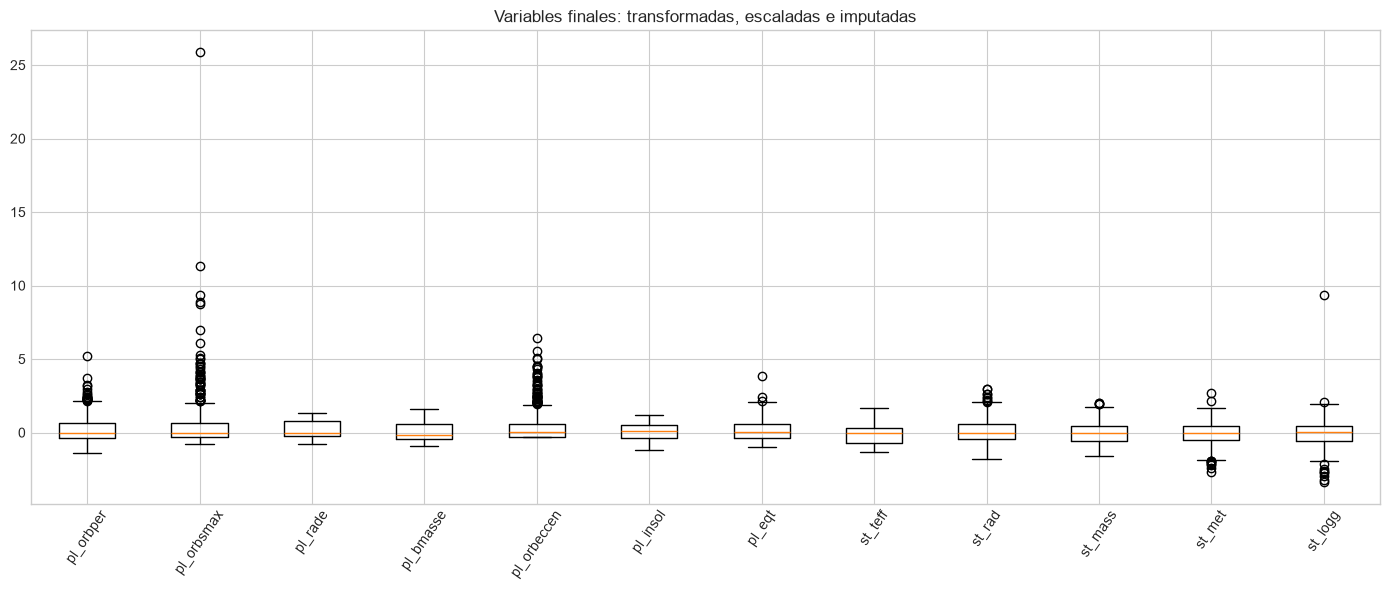

In [18]:
# BLOQUE 14B — Visualizar las distribuciones finales


fig, ax = plt.subplots(figsize=(14, 6))
ax.boxplot(
    [processed_features_df[column] for column in FEATURE_COLUMNS],
    tick_labels=FEATURE_COLUMNS,
    showfliers=True,
)
ax.set_title("Variables finales: transformadas, escaladas e imputadas")
ax.tick_params(axis="x", rotation=55)
fig.tight_layout()
plt.show()

In [19]:
# BLOQUE 14C — Ejecutar las comprobaciones automáticas

assert processed_df[ID_COLUMN].is_unique
assert len(processed_df) == int(retained_mask.sum()) == 675
assert processed_df.columns.tolist() == [ID_COLUMN, *FEATURE_COLUMNS]
assert not processed_df[FEATURE_COLUMNS].isna().any().any()
assert np.isfinite(processed_df[FEATURE_COLUMNS].to_numpy()).all()
assert (
    row_audit.loc[row_audit["retenido"], "variables_presentes"]
    >= MIN_PRESENT_FEATURES
).all()
assert row_audit.loc[row_audit["retenido"], YEAR_COLUMN].max() <= MAX_DISCOVERY_YEAR
assert not row_audit.loc[row_audit["retenido"], YEAR_COLUMN].eq(2026).any()

final_checks = pd.Series(
    {
        "filas_procesadas": len(processed_df),
        "año_máximo": int(
            row_audit.loc[row_audit["retenido"], YEAR_COLUMN].max()
        ),
        "variables_modelo": len(FEATURE_COLUMNS),
        "duplicados": int(processed_df[ID_COLUMN].duplicated().sum()),
        "nulos_finales": int(processed_df[FEATURE_COLUMNS].isna().sum().sum()),
        "no_finitos": int(
            (~np.isfinite(processed_df[FEATURE_COLUMNS].to_numpy())).sum()
        ),
    },
    name="resultado",
)
display(final_checks.to_frame())
print("Comprobaciones finales superadas.")

,resultado
filas_procesadas,675
año_máximo,2025
variables_modelo,12
duplicados,0
nulos_finales,0
no_finitos,0


Comprobaciones finales superadas.


### Conclusión del bloque 14

Las pruebas exigen **675 filas**, año máximo 2025, 12 variables, cero nulos, cero infinitos y cero identificadores duplicados.

## Bloque 15. Exportación y entrega


Se exportan el CSV para PCA, los datos originales seleccionados, auditorías, comparaciones, metadata y el pipeline entrenado. Crear las carpetas desde el código permite reproducir el flujo en otro equipo sin preparar directorios manualmente.

In [20]:
# BLOQUE 15A — Guardar datos, auditorías, metadata y pipeline

output_paths = {
    "processed_data": PROJECT_ROOT / PROCESSED_DATA_PATH,
    "selected_raw_data": PROJECT_ROOT / SELECTED_RAW_DATA_PATH,
    "row_audit": PROJECT_ROOT / ROW_AUDIT_PATH,
    "quality_summary": PROJECT_ROOT / QUALITY_SUMMARY_PATH,
    "scaler_comparison": PROJECT_ROOT / SCALER_COMPARISON_PATH,
    "imputer_comparison": PROJECT_ROOT / IMPUTER_COMPARISON_PATH,
    "pipeline": PROJECT_ROOT / PIPELINE_PATH,
    "metadata": PROJECT_ROOT / METADATA_PATH,
}

metadata = {
    "source": "NASA Exoplanet Archive - Planetary Systems (PS)",
    "source_url": NASA_SOURCE_URL,
    "input_path": str(RAW_DATA_PATH),
    "output_path": str(PROCESSED_DATA_PATH),
    "id_column": ID_COLUMN,
    "year_column": YEAR_COLUMN,
    "max_discovery_year": MAX_DISCOVERY_YEAR,
    "temporal_filter_rule": "disc_year <= 2025",
    "planet_features": PLANET_FEATURES,
    "stellar_features": STELLAR_FEATURES,
    "feature_columns": FEATURE_COLUMNS,
    "log1p_features": LOG1P_FEATURES,
    "linear_features": LINEAR_FEATURES,
    "minimum_present_features": MIN_PRESENT_FEATURES,
    "scaler": SCALER_NAME,
    "imputer": {
        "name": "KNNImputer",
        "n_neighbors": KNN_NEIGHBORS,
        "weights": KNN_WEIGHTS,
    },
    "outlier_policy": "preserve; audit with IQR; mitigate with log1p and robust scaling",
    "rows_raw": int(len(df_raw)),
    "rows_excluded_2026": int((~temporal_eligible_mask).sum()),
    "rows_eligible_through_2025": int(temporal_eligible_mask.sum()),
    "rows_excluded_completeness_through_2025": int(
        (~completeness_mask_eligible).sum()
    ),
    "rows_retained": int(len(processed_df)),
    "rows_excluded_total": int(len(df_raw) - len(processed_df)),
    "exported_at_utc": pd.Timestamp.now(tz="UTC").isoformat(),
}

if "missingness_retained" not in globals():
    missingness_retained = pd.DataFrame(
        {
            "nulos_en_retenidos": df_retained[FEATURE_COLUMNS].isna().sum(),
            "porcentaje_nulos_en_retenidos": (
                df_retained[FEATURE_COLUMNS].isna().mean() * 100
            ),
        }
    ).sort_values("porcentaje_nulos_en_retenidos", ascending=False)
    missingness_retained["nivel_riesgo"] = np.where(
        missingness_retained["porcentaje_nulos_en_retenidos"] >= 40,
        "alto",
        np.where(
            missingness_retained["porcentaje_nulos_en_retenidos"] >= 20,
            "medio",
            "bajo",
        ),
    )

quality_summary = (
    missingness_before
    .join(missingness_retained)
    .join(skewness_comparison)
    .join(outlier_summary[["outliers_iqr", "porcentaje_outliers"]])
)

if EXPORT_ARTIFACTS:
    output_paths["processed_data"].parent.mkdir(parents=True, exist_ok=True)
    processed_df.to_csv(output_paths["processed_data"], index=False)
    df_retained[[ID_COLUMN, *FEATURE_COLUMNS]].to_csv(
        output_paths["selected_raw_data"], index=False
    )
    row_audit.to_csv(output_paths["row_audit"], index=False)
    quality_summary.to_csv(output_paths["quality_summary"], index_label="variable")
    scaler_comparison.to_csv(output_paths["scaler_comparison"])
    imputer_comparison.to_csv(output_paths["imputer_comparison"])
    joblib.dump(preprocessing_pipeline, output_paths["pipeline"])
    output_paths["metadata"].write_text(
        json.dumps(metadata, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    print("Artefactos exportados:")
    for name, path in output_paths.items():
        print(f"- {name}: {path}")
else:
    print("Exportación desactivada.")

Artefactos exportados:
- processed_data: C:\PROYECTOS_ELE\BOOTCAMP_MODULO3\proyecto2_modulo3\exoplanet-profiler\data\processed\exoplanets_preprocessed.csv
- selected_raw_data: C:\PROYECTOS_ELE\BOOTCAMP_MODULO3\proyecto2_modulo3\exoplanet-profiler\data\processed\exoplanets_selected_raw.csv
- row_audit: C:\PROYECTOS_ELE\BOOTCAMP_MODULO3\proyecto2_modulo3\exoplanet-profiler\data\processed\preprocessing_row_audit.csv
- quality_summary: C:\PROYECTOS_ELE\BOOTCAMP_MODULO3\proyecto2_modulo3\exoplanet-profiler\data\processed\preprocessing_quality_summary.csv
- scaler_comparison: C:\PROYECTOS_ELE\BOOTCAMP_MODULO3\proyecto2_modulo3\exoplanet-profiler\data\processed\preprocessing_scaler_comparison.csv
- imputer_comparison: C:\PROYECTOS_ELE\BOOTCAMP_MODULO3\proyecto2_modulo3\exoplanet-profiler\data\processed\preprocessing_imputer_comparison.csv
- pipeline: C:\PROYECTOS_ELE\BOOTCAMP_MODULO3\proyecto2_modulo3\exoplanet-profiler\data\processed\preprocessing_pipeline.joblib
- metadata: C:\PROYECTOS_ELE

In [21]:
# BLOQUE 15B — Mostrar el resumen final

final_summary = pd.Series(
    {
        "planetas_originales": len(df_raw),
        "excluidos_2026": int((~temporal_eligible_mask).sum()),
        "elegibles_hasta_2025": int(temporal_eligible_mask.sum()),
        "planetas_procesados": len(processed_df),
        "porcentaje_conservado": len(processed_df) / len(df_raw) * 100,
        "variables_finales": len(FEATURE_COLUMNS),
        "variables_log1p": len(LOG1P_FEATURES),
        "scaler": SCALER_NAME,
        "imputer": f"KNN {KNN_NEIGHBORS} vecinos",
        "nulos_finales": int(processed_df[FEATURE_COLUMNS].isna().sum().sum()),
    },
    name="resultado",
)
display(final_summary.to_frame())

,resultado
planetas_originales,910
excluidos_2026,171
elegibles_hasta_2025,739
planetas_procesados,675
porcentaje_conservado,74.175824
variables_finales,12
variables_log1p,6
scaler,robust
imputer,KNN 5 vecinos
nulos_finales,0


### Conclusión del bloque 15 y siguientes pasos

El preprocessing queda listo para el notebook 04 con **675 planetas descubiertos hasta 2025**. El pipeline se ha ajustado exclusivamente sobre esta muestra.

Limitaciones:

- `pl_insol` depende de imputación en una parte importante de la muestra;
- KNN puede suavizar casos excepcionales;
- el corte de 2026 limita el alcance temporal y debe comunicarse;
- las cifras deben recalcularse si cambia el catálogo de NASA.